<table style="width: 100%; border-style: none;">
<tr style="border-style: none">
<td style="border-style: none; width: 1%; text-align: left; font-size: 16px">Institut f&uuml;r Theoretische Physik<br /> Universit&auml;t zu K&ouml;ln</td>
<td style="border-style: none; width: 1%; font-size: 16px">&nbsp;</td>
<td style="border-style: none; width: 1%; text-align: right; font-size: 16px">Prof. Dr. Matteo Rizzi
</tr>
</table>
<hr>
<h1 style="font-weight:bold; text-align: center; margin: 0px; font-size: 30px; padding:0px;">Computerphysik</h1>
<h1 style="font-weight:bold; text-align: center; margin: 0px; font-size: 30px; padding:0px;">Übungsblatt 9</h1>
<hr>
<h3 style="font-weight:bold; text-align: center; margin: 0px; font-size: 20px; padding:0px; margin-bottom: 20px;">Sommersemester 2026</h3>
<hr>


<table style="border-style: none; width: 100%"><tr style="border-style: none;">
<td style="border-style: none; width: 1%; text-align: left; font-size: 25px; font-weight: bold; text-decoration: underline">Aufgaben auf Übungsblatt 9</td>
<td style="border-style: none; width: 1%; text-align: right; font-size: 15px"></td></tr></table>

- Dendriten-Wachstum
- Random Walk
- Bestimmung von Pi

<table style="border-style: none; width: 100%"><tr style="border-style: none;">
<td style="border-style: none; width: 1%; text-align: left; font-size: 25px; font-weight: bold; text-decoration: underline">Aufgabe 2: Zufallslauf in einer Dimension und Diffusion</td>


In dieser Aufgabe wollen wir einen eindimensionalen *Zufallslauf* simulieren. Betrachten Sie dazu einen *Läufer* (L), der zur Zeit $t = 0$ an der Stelle $x = 0$ steht. Im Rahmen des Zufallslaufs geht L nun in jedem Zeitschritt einen Schritt der Länge $l$ nach rechts mit der Wahrscheinlichkeit $p$ oder nach links mit der Wahrscheinlichkeit $q = 1-p$. Insgesamt geht er $N = n_L + n_R$ Schritte, wobei $n_{L/R}$ die Anzahl der Schritte nach links/rechts ist.

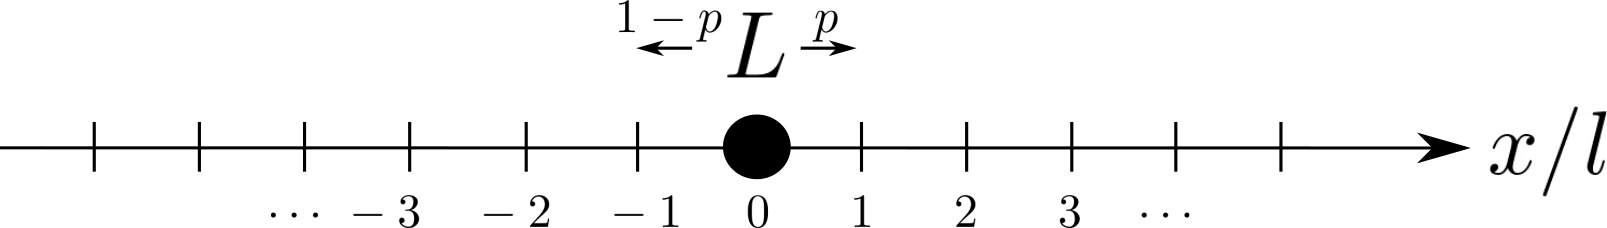

Ein typisches Beispiel für ein Phänomen, das durch einen Zufallslauf beschrieben werden kann, ist das der [Brownschen Begewung](https://en.wikipedia.org/wiki/Brownian_motion).

### a)

Leiten Sie zunächst analytisch für den symmetrischen Fall $(p = 1/2)$ Ausdrücke für die Erwartungswerte $\langle x_N \rangle$ sowie $\langle x^2_N \rangle$ her ($x_N$ ist die Position des Läufers nach $N$ Schritten). Erläutern Sie auch, was für eine Verteilung $P_N(x)$ der Wahrscheinlichkeit, dass $x$ die Endposition $N$ Schritten ist, Sie erwarten.

### Lösung a) (analytische Herleitung)

Für den symmetrischen Zufallslauf ist die Position nach $N$ Schritten
$$
x_N = l \sum_{k=1}^{N} s_k, \qquad s_k = \begin{cases} +1 & \text{mit } p=1/2 \\ -1 & \text{mit } q=1/2 \end{cases}
$$
wobei die $s_k$ unabhängig und identisch verteilt sind.

**Erwartungswert:**
$$
\langle x_N \rangle = l \sum_{k=1}^N \langle s_k \rangle = l \, N \, (p - q) = 0 \quad \text{für } p=q=1/2
$$

**Zweites Moment:** Da die $s_k$ unabhängig sind, verschwinden die Kreuzterme $\langle s_k s_j\rangle = \langle s_k\rangle\langle s_j\rangle = 0$ für $k\neq j$. Es bleibt
$$
\langle x_N^2 \rangle = l^2 \sum_{k=1}^N \langle s_k^2 \rangle = l^2 N,
$$
da $s_k^2 = 1$. Die Varianz $\mathrm{Var}(x_N) = \langle x_N^2\rangle - \langle x_N\rangle^2 = l^2 N$ wächst also **linear** mit der Schrittzahl $N$.

**Erwartete Verteilung $P_N(x)$:** $x_N/l$ ist eine Summe von $N$ unabhängigen $\pm1$-Variablen, also (verschoben) binomialverteilt. Nach dem zentralen Grenzwertsatz konvergiert dies für große $N$ gegen eine **Gauß-Verteilung**
$$
P_N(x) \approx \frac{1}{\sqrt{2\pi N l^2}}\exp\!\left(-\frac{x^2}{2Nl^2}\right),
$$
mit Mittelwert $0$ und Varianz $Nl^2$ — passend zu den oben berechneten Momenten. Die Breite der Verteilung wächst dabei wie $\sqrt{N}$, das typische Kennzeichen diffusiven Verhaltens.

### b)  

Nun wollen wir einen einfachen symmetrischen Zufallslauf simulieren und untersuchen. 

- Schreiben Sie dazu zunächst eine Funktion `schritt()`, die die Position von L in einem Schritt zufällig ändert.

- Nun schreiben Sie eine Funktion `lauf(N)`, die einen Läufer bei $x=0$ initialisiert, diesen $N$ Schritte gehen lässt und die resultierende Trajektorie ausgibt.

- Berechnen Sie die Trajektorien von 1000 Läufern, die jeweils 100 Schritte gehen, und Plotten diese in ein Diagramm. Plotten Sie auch die Endpunkte der Läufer in ein weiteres Diagramm sowie mit Hilfe von `hist()` ein Histogramm dieser Endpunkte. Zeichnen Sie darin auch eine Linie für den Mittelwert ein. Außerdem sollten Sie die Anzahl der Bins im Histogram so anzupassen, dass für jedes ganzzahlige $x/l$ genau ein Bin vorhanden ist. Schauen Sie sich dazu einmal `?hist` an.

- Nun variieren Sie die Anzahl der Schritte (z.B. nehmen Sie $N$ aus [100,500,1000,5000,10000,50000,100000]) und berechnen für jedes $N$ den Mittelwert und die Varianz der Endpositionen (Hinweis: Nutzen Sie `using Statistics`, dann können Sie Mittelwerte und Varianzen einfach mit `mean()` bzw. `var()` berechnen. Nehmen Sie weiterhin 1000 Läufer.). Plotten Sie den Mittelwert und die Varianz als Funktion von N.

Decken sich Ihre Beobachtungen mit Ihren Vorüberlegungen aus Teil a)? Diskutieren Sie in der Übung.

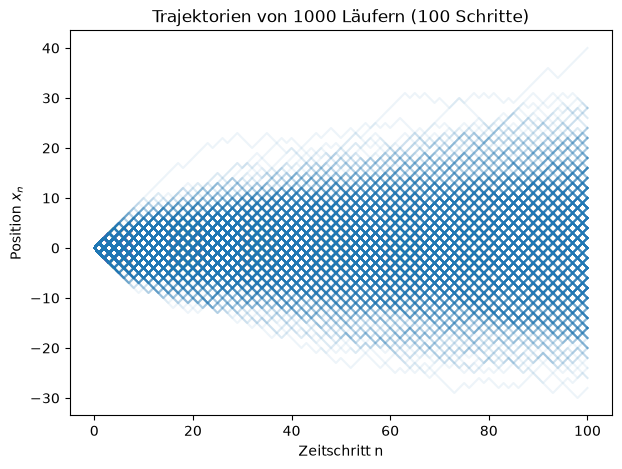

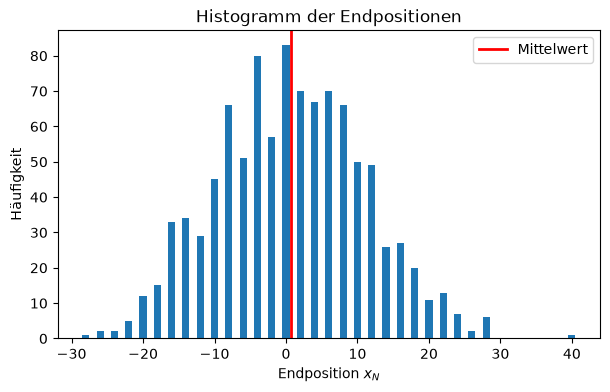

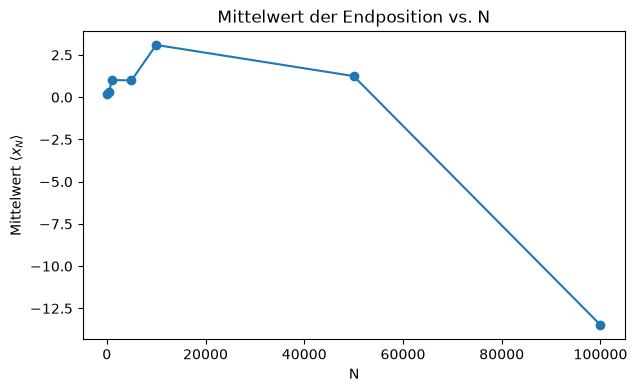

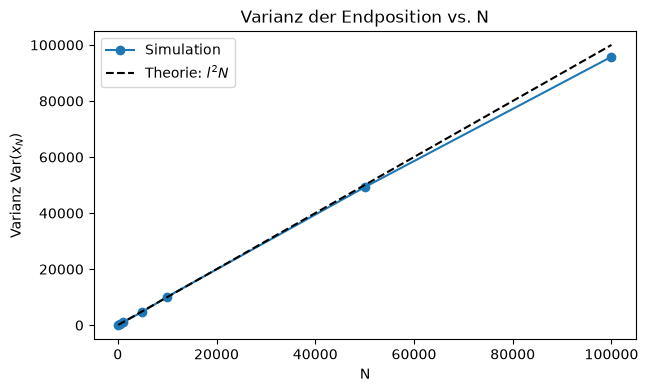

Mittelwerte: [0.172, 0.314, 1.018, 0.99, 3.092, 1.25, -13.48]
Varianzen:   [94.12854454454452, 502.3757797797797, 1005.8695455455457, 4802.306206206205, 10117.589125125125, 49237.158658658656, 95783.75335335336]


In [5]:
using PyPlot, Statistics

# Einzelner Schritt: mit Wahrscheinlichkeit 1/2 nach links (-l) oder rechts (+l)
function schritt(l=1)
    return rand() < 0.5 ? -l : l
end

# Trajektorie eines Läufers über N Schritte, startend bei x=0
function lauf(N; l=1)
    x = zeros(Float64, N+1)
    for n in 1:N
        x[n+1] = x[n] + schritt(l)
    end
    return x
end

# --- 1000 Läufer, je 100 Schritte ---
nwalkers = 1000
nsteps   = 100

trajektorien = [lauf(nsteps) for _ in 1:nwalkers]

# Trajektorien plotten
figure(figsize=(7,5))
for traj in trajektorien
    plot(0:nsteps, traj, alpha=0.08, color="C0")
end
xlabel("Zeitschritt n")
ylabel(L"Position $x_n$")
title("Trajektorien von $nwalkers Läufern ($nsteps Schritte)")
savefig("b_trajektorien.png", dpi=120)
display(gcf())

# Endpunkte extrahieren
endpunkte = [traj[end] for traj in trajektorien]

# Endpunkte als Streudiagramm
figure(figsize=(7,4))
plot(1:nwalkers, endpunkte, "o", markersize=2, alpha=0.6)
xlabel("Läufer-Index")
ylabel(L"Endposition $x_N$")
title("Endpositionen der $nwalkers Läufer")
savefig("b_endpunkte.png", dpi=120)

# Histogramm der Endpunkte (ein Bin pro ganzzahligem x/l)
figure(figsize=(7,4))
bins = (minimum(endpunkte)-0.5):1:(maximum(endpunkte)+0.5)
hist(endpunkte, bins=bins)
axvline(mean(endpunkte), color="red", linewidth=2, label="Mittelwert")
xlabel(L"Endposition $x_N$")
ylabel("Häufigkeit")
legend()
title("Histogramm der Endpositionen")
savefig("b_histogramm.png", dpi=120)
display(gcf())

# --- Mittelwert und Varianz als Funktion von N ---
Ns = [100, 500, 1000, 5000, 10000, 50000, 100000]
mittelwerte = Float64[]
varianzen   = Float64[]

for N in Ns
    endp = [lauf(N)[end] for _ in 1:1000]
    push!(mittelwerte, mean(endp))
    push!(varianzen, var(endp))
end

figure(figsize=(7,4))
plot(Ns, mittelwerte, "o-")
xlabel("N")
ylabel(L"Mittelwert $\langle x_N \rangle$")
title("Mittelwert der Endposition vs. N")
savefig("b_mittelwert_vs_N.png", dpi=120)
display(gcf())

figure(figsize=(7,4))
plot(Ns, varianzen, "o-", label="Simulation")
plot(Ns, Ns, "k--", label=L"Theorie: $l^2 N$")
xlabel("N")
ylabel(L"Varianz $\mathrm{Var}(x_N)$")
legend()
title("Varianz der Endposition vs. N")
savefig("b_varianz_vs_N.png", dpi=120)
display(gcf())

println("Mittelwerte: ", mittelwerte)
println("Varianzen:   ", varianzen)

# -> Mittelwerte schwanken um 0 (Rauschen, da nur 1000 Läufer pro N),
#    Varianzen wachsen linear mit N - in guter Übereinstimmung mit Teil a).

### c)

Nun wollen wir die Sache aus einer anderen Perspektive betrachten und gehen auf das Phänomen der Diffusion ein. Betrachten Sie dazu ein ein eindimensionales Gitter mit $2L+1$ Plätzen. Auf jedem dieser Plätze können sich Teilchen befinden und es gebe insgesamt $N$ Teilchen und die Anzahl der Teilchen auf dem $i.$ Gitterplatz zur Zeit $t$ sei $N_i(t)$. Zu Beginn seien alle Teilchen auf dem gleichen Gitterplatz, z.B. in der Mitte des Gitters, d.h. $N_0(t_0) = N, N_{i\neq 0}(t_0) = 0$. Die Teilchen können sich nun pro Zeitschritt $\Delta t$ entweder einen Platz nach links bewegen (mit der Wahrscheinlichkeit $p = R\Delta t$), einen Platz nach rechts bewegen (ebenfalls mit der Wahrscheinlichkeit $p$) oder auf Ihrem aktuellen Platz verweilen (mit der Wahrscheinlichkeit $1-2p$).

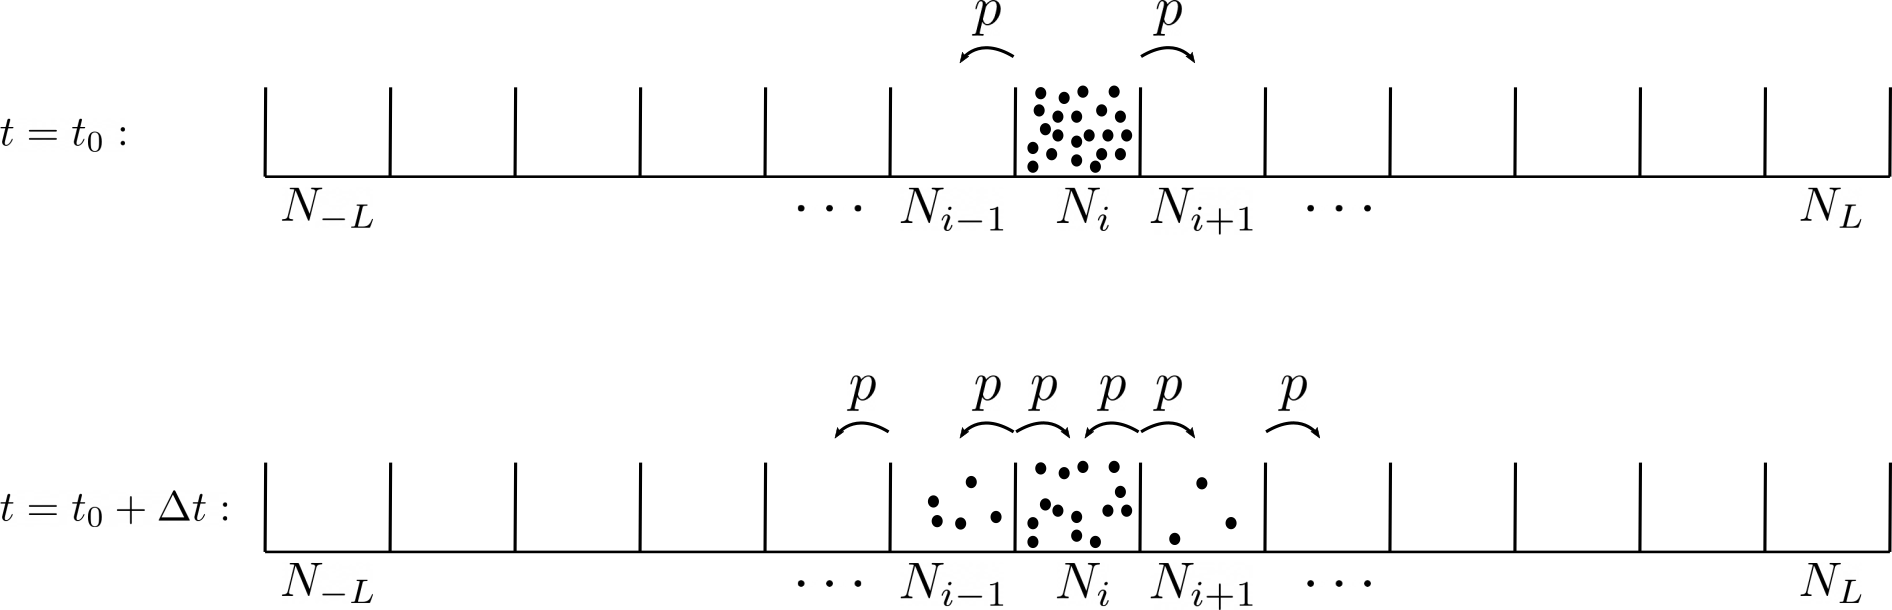

Die Teilchen diffundieren so also mit der Zeit auseinander. Dieser Diffusionsprozess kann mathematisch mithilfe der *Diffusionsgleichung* beschrieben werden:

$$
\frac{\partial N(x,t)}{\partial t} = D \frac{\partial^2 N(x,t)}{\partial x^2}
$$
mit der Diffusionskonstanten $D = R\Delta x^2$.

- Diskretisieren Sie diese Gleichung und finden Sie einen Ausdruck für $N_i(t+\Delta t)$. Hinweis: Darin sollte die Diffusionskonstante $D$ nicht mehr vorkommen, sondern stattdessen nur noch die Wahrscheinlichkeit $p = R\Delta t$.
- Initialisieren Sie das Gitter mit 2L+1 Plätzen und starten Sie mit N = 5000 Teilchen in der Mitte des Gitters wie oben beschrieben.
- Lösen Sie die Diffusionsgleichung, um $N(x,t)$ für den Zeitpunk $T = 100$ zu erhalten (d.h. machen Sie 100 Iterationsschritte mit $\Delta t = 1$). Die Wahrscheinlichkeit $p$ sei dabei 0.1.
- Parallel, **aber unabhängig davon**, machen Sie einen eindimensionalen Zufallslauf wie in Aufgabenteil b) mit 5000 Läufern die jeweils 100 Schritte gehen, jedoch nun unter Berücksichtigung der neuen Wahrscheinlichkeiten, d.h. Sie gehen mit Wahrscheinlichkeit $p = 0.1$ nach links, mit gleicher Wahrscheinlichkeit $p$ nach rechts oder bleiben mit Wahrscheinlichkeit $1-2p$ stehen.
- Plotten Sie danach die Konzentration $N(x,t)$ sowie das Histogramm der Endpositionen des Zufallslauf gemeinsam in ein Diagramm (die Anzahl der Bins des Histogramms sollte wieder so gewahlt sein, dass für jeden Gitterplatz genau ein Bin genutzt wird).

Beschreiben Sie Ihr Ergebnis!

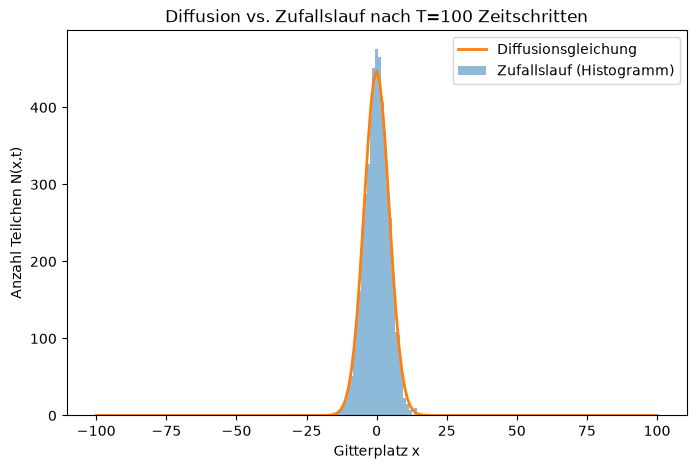

In [4]:
using PyPlot, Statistics

# --- Diskretisierung der Diffusionsgleichung ---
# ∂N/∂t = D ∂²N/∂x²  mit zentraler Differenz für die zweite Ableitung:
#   N_i(t+Δt) = N_i(t) + (D Δt / Δx²) [N_{i+1}(t) - 2 N_i(t) + N_{i-1}(t)]
# Mit D = R Δx² und p = R Δt folgt  D Δt / Δx² = R Δt = p, also:
#   N_i(t+Δt) = p N_{i+1}(t) + p N_{i-1}(t) + (1-2p) N_i(t)
# Das entspricht genau der Wahrscheinlichkeitsinterpretation: ein Teilchen bleibt
# mit Wahrscheinlichkeit (1-2p), oder kommt von links/rechts mit Wahrscheinlichkeit p.

L = 100
N_teilchen = 5000
p = 0.1
T = 100

# --- Gitter-Lösung der Diffusionsgleichung ---
N_t = zeros(Float64, 2L+1)
N_t[L+1] = N_teilchen   # alle Teilchen starten in der Mitte

for t in 1:T
    N_neu = copy(N_t)
    for i in 2:2L          # innere Gitterplätze
        N_neu[i] = p*N_t[i+1] + p*N_t[i-1] + (1-2p)*N_t[i]
    end
    # Ränder: keine Teilchen kommen "von außen" hinein
    N_neu[1]    = p*N_t[2]    + (1-2p)*N_t[1]
    N_neu[2L+1] = p*N_t[2L]   + (1-2p)*N_t[2L+1]
    N_t = N_neu
end

# --- Unabhängiger Zufallslauf mit denselben Wahrscheinlichkeiten ---
function schritt_diffusion(p)
    r = rand()
    if r < p
        return -1        # nach links
    elseif r < 2p
        return 1          # nach rechts
    else
        return 0          # stehen bleiben
    end
end

function lauf_diffusion(N, p)
    x = 0
    for n in 1:N
        x += schritt_diffusion(p)
    end
    return x
end

endpunkte = [lauf_diffusion(T, p) for _ in 1:N_teilchen]

# --- Vergleich: Diffusionsgleichung vs. Zufallslauf-Histogramm ---
x_werte = -L:L

figure(figsize=(8,5))
plot(x_werte, N_t, color="C1", linewidth=2, label="Diffusionsgleichung")
bins = (-L-0.5):1:(L+0.5)   # ein Bin pro Gitterplatz
hist(endpunkte, bins=bins, alpha=0.5, color="C0", label="Zufallslauf (Histogramm)")
xlabel("Gitterplatz x")
ylabel("Anzahl Teilchen N(x,t)")
legend()
title("Diffusion vs. Zufallslauf nach T=$T Zeitschritten")
savefig("c_diffusion_vergleich.png", dpi=120)
display(gcf())

# -> Beide Methoden liefern dieselbe (näherungsweise gaußförmige) Verteilung:
#    Die diskretisierte Diffusionsgleichung beschreibt im Mittel exakt dasselbe
#    Verhalten wie das Histogramm der vielen unabhängigen Zufallsläufer -
#    makroskopische Diffusion ist nichts anderes als das gemittelte Resultat
#    vieler mikroskopischer Zufallsläufe.

### d) Bonus: Quantum Walk in einer Dimension 

Ein [Quantum Walk](https://en.wikipedia.org/wiki/Quantum_walk) ist das quantenmechanische Analogon zum klassischen Zufallslauf (interessierte Leser finden [hier](https://arxiv.org/pdf/quant-ph/0303081.pdf) oder [hier](https://arxiv.org/pdf/quant-ph/0010117.pdf) mehr dazu). Anders als beim klassischen Zufallslauf beruht die Zufälligkeit im Quantum Walk nicht auf zufälligen Positionswechseln, sondern auf quantenmechanischen Effekten wie dem Superpositionsprinzip oder dem Kollaps der Wellenfunktion nach einer Messung. Insbesondere konvergieren sie dadurch nicht asymptotisch gegen eine bestimmte Verteilung.


Die Zeitentwicklung während eines Quantum Walks wird durch zwei Dinge bestimmt, nämlich durch einen "Münzwurf"-Operator $M$ sowie einen Verschiebungsoperator $V$, die wiederholt angewandt werden.

Um dies zu veranschaulichen, stellen Sie sich ein Spin-$1/2$-Teilchen vor, das sich auf einem eindimensionalen Gitter mit $2L+1$ Plätzen bewegt. Dessen Zustand kann als Produkt $|\psi\rangle = |s\rangle \otimes |i\rangle$ des Spinzustands 

$$
|s\rangle \in \mathcal{H}_M = \lbrace\alpha\vert\uparrow\rangle\ + \beta\vert\downarrow\rangle : \alpha, \beta \in \mathbb{C}\rbrace
$$ 

sowie der Position 

$$
|i\rangle \in \mathcal{H}_P = \lbrace\vert n \rangle\ : n = -L,-L+1,\dots,L-1,L\rbrace
$$ 

beschrieben werden, wobei wir $\mathcal{H}_M$ den Münzraum nennen und $\mathcal{H}_P$ den Positionsraum.

Der Verschiebungsoperator $V$ für das Teilchen ist gegeben durch

$$
V = |\uparrow\rangle\langle\uparrow| \otimes \sum_i |i+1\rangle\langle i| + |\downarrow\rangle\langle\downarrow| \otimes \sum_i |i-1\rangle\langle i|
$$ 

D.h. das Teilchen springt also nach rechts bei nach oben zeigendem Spin und nach links bei nach unten zeigendem Spin.

Rotieren wir zuvor den Spin mit einer unitären Transformation $M$ - dem Münzwurf - und wenden dann $V$ an, so erhalten wir eine nicht-triviale Bewegung des Teilchens auf dem Gitter. Eine übliche Wahl für $M$ ist das Hadamard-Gate $H$, 

$$
M = H = \frac{1}{\sqrt{2}} \left(\begin{array}{rr} 
1 & 1 \\ 
1 & -1 \\ 
\end{array}\right)
$$

Beachten Sie, dass $M$ nur auf dem Münzraum (d.h. auf die Spinzustände) wirkt, nicht auf dem Positionsraum. Genau genommen ist der Münzoperator also $M \otimes \mathbb{1}$.

Ihre Aufgabe ist es nun, einen solchen Quantum Walk zu implementieren. Gehen Sie dazu wie folgt vor:

- Schreiben Sie Funktionen für den Münzoperator und den Verschiebungsoperator. Vergessen Sie dabei nicht die Normalisierung nach jedem Schritt.

- Initialisieren Sie einen Anfangszustand 
$$
|\psi_0\rangle = \frac{1}{\sqrt{2}} (|\uparrow\rangle + i |\downarrow\rangle) \otimes |0\rangle
$$
Das Teilchen startet also in der Mitte des Gitters. Nehmen Sie L = 100, so dass das Giter 201 Plätze hat.

- Iterieren Sie nun 100 Schritte des Quantum Walks - wenden Sie also 100 mal zunächst $M$ und dann $V$ auf Ihren Zustand an.

- Plotten Sie die Aufenthaltswahrscheinlichkeit des Teilchens auf dem Gitter nach diesen 100 Schritten. Versuchen Sie das gleiche auch gerne mit anderen Anfangszuständen, z.B. $|\tilde{\psi}_0\rangle = |\uparrow\rangle \otimes |0\rangle$.

In [ ]:
using PyPlot

L = 100
dim = 2L + 1

# --- Münzoperator (Hadamard-Gate) ---
H = (1/sqrt(2)) * [1.0+0im 1.0+0im; 1.0+0im -1.0+0im]

function muenzwurf!(psi, M)
    # M wirkt auf den Spinindex (1. Dimension) an jedem Gitterplatz
    for i in 1:size(psi,2)
        psi[:, i] = M * psi[:, i]
    end
end

function verschiebung!(psi)
    # |↑⟩-Komponente springt nach rechts, |↓⟩-Komponente nach links
    dim = size(psi, 2)
    psi_neu = zeros(ComplexF64, 2, dim)
    for i in 1:dim
        if i < dim
            psi_neu[1, i+1] += psi[1, i]
        end
        if i > 1
            psi_neu[2, i-1] += psi[2, i]
        end
    end
    psi .= psi_neu
end

function normalisiere!(psi)
    norm_psi = sqrt(sum(abs2.(psi)))
    psi ./= norm_psi
end

# --- Anfangszustand |ψ0⟩ = 1/√2 (|↑⟩ + i|↓⟩) ⊗ |0⟩, Teilchen in Gittermitte ---
psi = zeros(ComplexF64, 2, dim)
psi[1, L+1] = 1/sqrt(2)        # Spin up
psi[2, L+1] = 1im/sqrt(2)      # Spin down

# --- 100 Schritte: erst Münzwurf M, dann Verschiebung V ---
nsteps = 100
for t in 1:nsteps
    muenzwurf!(psi, H)
    verschiebung!(psi)
    normalisiere!(psi)
end

# Aufenthaltswahrscheinlichkeit = Summe der Spin-Komponenten
wahrscheinlichkeit = abs2.(psi[1, :]) .+ abs2.(psi[2, :])

x_werte = -L:L
figure(figsize=(8,5))
plot(x_werte, wahrscheinlichkeit)
xlabel("Gitterplatz x")
ylabel("Aufenthaltswahrscheinlichkeit")
title("Quantum Walk nach $nsteps Schritten (Startzustand symmetrisch)")
savefig("d_quantum_walk.png", dpi=120)

# -> Typisch für den Quantum Walk: zwei symmetrische Peaks, die sich
#    ballistisch (∝ t) statt diffusiv (∝ √t) vom Ursprung entfernen,
#    mit komplexer Interferenzstruktur in der Mitte - im Gegensatz zum
#    klassischen Zufallslauf, der eine einzelne Gauß-Glocke ergibt.